# Stage 04 — German Credit Model Training

Final model selection is based only on five-fold cross-validation within the 800 training rows. The frozen test set is evaluated once after selection.


## 1. Frozen inputs


In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

RANDOM_STATE = 42
DECISION_THRESHOLD = 0.50
RAW_TARGET = "class"
TARGET = "TARGET"

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "german_credit":
    candidate = NOTEBOOK_DIR / "backend" / "ml" / "german_credit"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
    else:
        raise RuntimeError("Run from backend/ml/german_credit or the project root.")
BACKEND_DIR = NOTEBOOK_DIR.parents[1]
RAW_PATH = BACKEND_DIR / "data" / "german_credit" / "raw" / "german_credit_raw.csv"
ARTIFACTS_DIR = BACKEND_DIR / "artifacts" / "german_credit"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
SELECTED_PATH = ARTIFACTS_DIR / "selected_features.json"
PREPROCESSOR_PATH = ARTIFACTS_DIR / "preprocessor.joblib"
PREPROCESSING_METADATA_PATH = ARTIFACTS_DIR / "preprocessing_metadata.json"
TRAIN_INDICES_PATH = ARTIFACTS_DIR / "train_indices.csv"
TEST_INDICES_PATH = ARTIFACTS_DIR / "test_indices.csv"
TRANSFORMED_MAPPING_PATH = ARTIFACTS_DIR / "transformed_feature_mapping.csv"
STAGE03_RECOMMENDATION_PATH = ARTIFACTS_DIR / "stage03_recommendation.json"
MODEL_PATH = ARTIFACTS_DIR / "xgboost_credit_model.joblib"
MODEL_METADATA_PATH = ARTIFACTS_DIR / "model_metadata.json"
XAI_CASES_PATH = ARTIFACTS_DIR / "xai_evaluation_cases.csv"

previous_metadata = json.loads(MODEL_METADATA_PATH.read_text(encoding="utf-8")) if MODEL_METADATA_PATH.exists() else {}
previous_model_name = previous_metadata.get("selected_model_name")
previous_xai_cases = pd.read_csv(XAI_CASES_PATH) if XAI_CASES_PATH.exists() else pd.DataFrame()


In [2]:
raw_df = pd.read_csv(RAW_PATH)
selection = json.loads(SELECTED_PATH.read_text(encoding="utf-8"))
preprocessing_metadata = json.loads(PREPROCESSING_METADATA_PATH.read_text(encoding="utf-8"))
stage03_recommendation = json.loads(STAGE03_RECOMMENDATION_PATH.read_text(encoding="utf-8"))
train_indices = pd.read_csv(TRAIN_INDICES_PATH)["row_index"].astype(int)
test_indices = pd.read_csv(TEST_INDICES_PATH)["row_index"].astype(int)
transformed_mapping = pd.read_csv(TRANSFORMED_MAPPING_PATH, keep_default_na=False)
preprocessor = joblib.load(PREPROCESSOR_PATH)

selected_features = selection["selected_features"]
y_all = raw_df[RAW_TARGET].map({1: 0, 2: 1}).rename(TARGET)
X_train_raw = raw_df.loc[train_indices, selected_features].copy()
X_test_raw = raw_df.loc[test_indices, selected_features].copy()
y_train = y_all.loc[train_indices].copy()
y_test = y_all.loc[test_indices].copy()
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
transformed_feature_names = preprocessor.get_feature_names_out()

assert X_train_processed.shape == (800, 54)
assert X_test_processed.shape == (200, 54)
assert y_train.value_counts().to_dict() == {0: 560, 1: 240}
assert y_test.value_counts().to_dict() == {0: 140, 1: 60}
assert np.isfinite(X_train_processed).all() and np.isfinite(X_test_processed).all()
assert transformed_feature_names.tolist() == transformed_mapping["transformed_feature"].tolist()
print(f"Training matrix: {X_train_processed.shape}")
print(f"Test matrix: {X_test_processed.shape}")


Training matrix: (800, 54)
Test matrix: (200, 54)


## 2. Fixed candidates and selection rule

The three existing configurations are retained. A model is eligible when its mean CV ROC-AUC and average precision are each within 0.01 of the corresponding best mean.

Eligible models are ranked by lower mean UCI cost, then higher positive F1, balanced accuracy and ROC-AUC. This rule is fixed before calculating the comparison.


In [3]:
BASELINE_PARAMETERS = {
    "objective": "binary:logistic", "eval_metric": "logloss",
    "n_estimators": 200, "max_depth": 3, "learning_rate": 0.05,
    "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8,
    "reg_alpha": 0.0, "reg_lambda": 1.0,
    "random_state": RANDOM_STATE, "n_jobs": 1, "tree_method": "hist",
}
CV_SELECTED_PARAMETERS = {
    "objective": "binary:logistic", "eval_metric": "logloss",
    "n_estimators": 200, "max_depth": 4, "learning_rate": 0.05,
    "min_child_weight": 1, "subsample": 0.9, "colsample_bytree": 0.9,
    "reg_alpha": 0.1, "reg_lambda": 5.0,
    "random_state": RANDOM_STATE, "n_jobs": 1, "tree_method": "hist",
}
scale_pos_weight = float(y_train.eq(0).sum() / y_train.eq(1).sum())
WEIGHTED_PARAMETERS = {**CV_SELECTED_PARAMETERS, "scale_pos_weight": scale_pos_weight}

candidate_estimators = {
    "Baseline XGBoost": XGBClassifier(**BASELINE_PARAMETERS),
    "CV-selected XGBoost": XGBClassifier(**CV_SELECTED_PARAMETERS),
    "Weighted XGBoost": XGBClassifier(**WEIGHTED_PARAMETERS),
}
SELECTION_TOLERANCE = 0.01
print(f"Candidates: {list(candidate_estimators)}")
print(f"scale_pos_weight: {scale_pos_weight:.6f}")
print(f"Ranking tolerance: {SELECTION_TOLERANCE:.2f}")


Candidates: ['Baseline XGBoost', 'CV-selected XGBoost', 'Weighted XGBoost']
scale_pos_weight: 2.333333
Ranking tolerance: 0.01


## 3. Training-only cross-validation comparison

All metrics and costs in this section use validation folds drawn from the training partition. The 200-row holdout is not referenced.


In [4]:
official_cost_matrix = stage03_recommendation["uci_cost_matrix"]
assert official_cost_matrix == {
    "actual_1_predicted_1": 0, "actual_1_predicted_2": 1,
    "actual_2_predicted_1": 5, "actual_2_predicted_2": 0,
}

def classification_metrics(y_true, probabilities, threshold=DECISION_THRESHOLD):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision_positive": precision_score(y_true, predictions, zero_division=0),
        "recall_positive": recall_score(y_true, predictions, zero_division=0),
        "f1_positive": f1_score(y_true, predictions, zero_division=0),
        "uci_cost": int(fp + 5 * fn),
        "false_positive": int(fp), "false_negative": int(fn),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_rows = []
for model_name, estimator in candidate_estimators.items():
    for fold_number, (fit_positions, validation_positions) in enumerate(cv.split(X_train_processed, y_train), start=1):
        fold_model = clone(estimator)
        started = time.perf_counter()
        fold_model.fit(X_train_processed[fit_positions], y_train.iloc[fit_positions])
        fit_seconds = time.perf_counter() - started
        fold_probabilities = fold_model.predict_proba(X_train_processed[validation_positions])[:, 1]
        metrics = classification_metrics(y_train.iloc[validation_positions], fold_probabilities)
        fold_rows.append({
            "model": model_name, "aggregation": f"fold_{fold_number}",
            "fold": fold_number, **metrics, "fit_time_seconds": fit_seconds,
        })
cv_fold_results = pd.DataFrame(fold_rows)
metric_columns = [
    "roc_auc", "pr_auc", "balanced_accuracy", "precision_positive",
    "recall_positive", "f1_positive", "uci_cost",
    "false_positive", "false_negative", "fit_time_seconds",
]
summary_rows = []
for model_name, group in cv_fold_results.groupby("model", sort=False):
    for aggregation, function in [("mean", "mean"), ("std", "std")]:
        values = group[metric_columns].agg(function)
        summary_rows.append({
            "model": model_name, "aggregation": aggregation, "fold": np.nan,
            **values.to_dict(),
        })
cv_model_comparison = pd.concat([cv_fold_results, pd.DataFrame(summary_rows)], ignore_index=True)
CV_MODEL_COMPARISON_PATH = ARTIFACTS_DIR / "cv_model_comparison.csv"
cv_model_comparison.to_csv(CV_MODEL_COMPARISON_PATH, index=False)

cv_means = cv_model_comparison.loc[cv_model_comparison["aggregation"].eq("mean")].copy()
cv_stds = cv_model_comparison.loc[cv_model_comparison["aggregation"].eq("std")].copy()
display(cv_means)
display(cv_stds)


,model,aggregation,fold,roc_auc,pr_auc,balanced_accuracy,precision_positive,recall_positive,f1_positive,uci_cost,false_positive,false_negative,fit_time_seconds
15,Baseline XGBoost,mean,NaN,0.793415,0.630956,0.666369,0.618195,0.454167,0.521752,144.6,13.6,26.2,0.068956
17,CV-selected XGBoost,mean,NaN,0.798549,0.631951,0.678274,0.639929,0.470833,0.540223,139.8,12.8,25.4,0.069657
19,Weighted XGBoost,mean,NaN,0.798847,0.629046,0.730655,0.570913,0.679167,0.619748,101.4,24.4,15.4,0.067562


,model,aggregation,fold,roc_auc,pr_auc,balanced_accuracy,precision_positive,recall_positive,f1_positive,uci_cost,false_positive,false_negative,fit_time_seconds
16,Baseline XGBoost,std,NaN,0.047846,0.065139,0.040459,0.085788,0.071261,0.068895,17.798876,3.646917,3.420526,0.015033
18,CV-selected XGBoost,std,NaN,0.047665,0.073166,0.035331,0.062831,0.073065,0.059807,16.961722,3.033150,3.507136,0.004662
20,Weighted XGBoost,std,NaN,0.049192,0.079970,0.062038,0.070597,0.101636,0.082061,26.735744,3.781534,4.878524,0.004673


## 4. Training-only final selection


In [5]:
highest_cv_roc_auc = float(cv_means["roc_auc"].max())
highest_cv_pr_auc = float(cv_means["pr_auc"].max())
cv_means["ranking_eligible"] = (
    cv_means["roc_auc"].ge(highest_cv_roc_auc - SELECTION_TOLERANCE)
    & cv_means["pr_auc"].ge(highest_cv_pr_auc - SELECTION_TOLERANCE)
)
eligible_models = cv_means.loc[cv_means["ranking_eligible"]].copy()
selected_cv_row = eligible_models.sort_values(
    ["uci_cost", "f1_positive", "balanced_accuracy", "roc_auc"],
    ascending=[True, False, False, False],
).iloc[0]
selected_final_model_name = selected_cv_row["model"]
selection_reason = (
    f"{selected_final_model_name} passed both 0.01 ranking tolerances and ranked first "
    "by mean out-of-fold UCI cost, followed by F1, balanced accuracy and ROC-AUC."
)

print(f"Highest CV ROC-AUC: {highest_cv_roc_auc:.6f}")
print(f"Highest CV PR-AUC: {highest_cv_pr_auc:.6f}")
print(f"Eligible models: {eligible_models['model'].tolist()}")
print(f"Selected final model: {selected_final_model_name}")
print(f"Selection reason: {selection_reason}")


Highest CV ROC-AUC: 0.798847
Highest CV PR-AUC: 0.631951
Eligible models: ['Baseline XGBoost', 'CV-selected XGBoost', 'Weighted XGBoost']
Selected final model: Weighted XGBoost
Selection reason: Weighted XGBoost passed both 0.01 ranking tolerances and ranked first by mean out-of-fold UCI cost, followed by F1, balanced accuracy and ROC-AUC.


## 5. Fit selected model and evaluate the holdout

The selected configuration is fitted once on all 800 training rows. The frozen 200-row test set is then used for final evaluation only.


In [6]:
final_model = clone(candidate_estimators[selected_final_model_name])
final_fit_started = time.perf_counter()
final_model.fit(X_train_processed, y_train)
final_training_time = time.perf_counter() - final_fit_started
final_probabilities = final_model.predict_proba(X_test_processed)[:, 1]
final_predictions = (final_probabilities >= DECISION_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, final_predictions, labels=[0, 1]).ravel()
final_metrics = {
    "roc_auc": roc_auc_score(y_test, final_probabilities),
    "pr_auc": average_precision_score(y_test, final_probabilities),
    "accuracy": accuracy_score(y_test, final_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, final_predictions),
    "precision_positive": precision_score(y_test, final_predictions, zero_division=0),
    "recall_positive": recall_score(y_test, final_predictions, zero_division=0),
    "f1_positive": f1_score(y_test, final_predictions, zero_division=0),
    "true_negative": int(tn), "false_positive": int(fp),
    "false_negative": int(fn), "true_positive": int(tp),
    "predicted_negative_count": int((final_predictions == 0).sum()),
    "predicted_positive_count": int((final_predictions == 1).sum()),
    "uci_total_cost": int(fp + 5 * fn),
    "uci_average_cost": float((fp + 5 * fn) / len(y_test)),
}
final_confusion = np.array([[tn, fp], [fn, tp]])
display(pd.Series(final_metrics, name="value").to_frame())
display(pd.DataFrame(final_confusion, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))


,value
roc_auc,0.790595
pr_auc,0.658808
accuracy,0.760000
balanced_accuracy,0.757143
precision_positive,0.576923
recall_positive,0.750000
f1_positive,0.652174
true_negative,107.000000
false_positive,33.000000
false_negative,15.000000


,Predicted 0,Predicted 1
Actual 0,107,33
Actual 1,15,45


## 6. CV model comparison artifact

The general comparison artifact now contains training-CV means and standard deviations. Holdout metrics are stored only for the selected final model in metadata.


In [7]:
comparison_rows = []
for row in cv_means.itertuples(index=False):
    std_row = cv_stds.loc[cv_stds["model"].eq(row.model)].iloc[0]
    comparison_rows.append({
        "model": row.model,
        "roc_auc": row.roc_auc, "roc_auc_std": std_row["roc_auc"],
        "pr_auc": row.pr_auc, "pr_auc_std": std_row["pr_auc"],
        "balanced_accuracy": row.balanced_accuracy,
        "balanced_accuracy_std": std_row["balanced_accuracy"],
        "precision_positive": row.precision_positive,
        "precision_positive_std": std_row["precision_positive"],
        "recall_positive": row.recall_positive,
        "recall_positive_std": std_row["recall_positive"],
        "f1_positive": row.f1_positive, "f1_positive_std": std_row["f1_positive"],
        "uci_total_cost": row.uci_cost, "uci_total_cost_std": std_row["uci_cost"],
        "training_time_seconds": row.fit_time_seconds,
        "ranking_eligible": bool(row.ranking_eligible),
        "selected_final_model": row.model == selected_final_model_name,
        "evaluation_scope": "five-fold training cross-validation",
    })
model_comparison = pd.DataFrame(comparison_rows)
MODEL_COMPARISON_PATH = ARTIFACTS_DIR / "model_comparison.csv"
model_comparison.to_csv(MODEL_COMPARISON_PATH, index=False)
display(model_comparison)


,model,roc_auc,roc_auc_std,pr_auc,pr_auc_std,balanced_accuracy,balanced_accuracy_std,precision_positive,precision_positive_std,recall_positive,recall_positive_std,f1_positive,f1_positive_std,uci_total_cost,uci_total_cost_std,training_time_seconds,ranking_eligible,selected_final_model,evaluation_scope
0,Baseline XGBoost,0.793415,0.047846,0.630956,0.065139,0.666369,0.040459,0.618195,0.085788,0.454167,0.071261,0.521752,0.068895,144.6,17.798876,0.068956,True,False,five-fold training cross-validation
1,CV-selected XGBoost,0.798549,0.047665,0.631951,0.073166,0.678274,0.035331,0.639929,0.062831,0.470833,0.073065,0.540223,0.059807,139.8,16.961722,0.069657,True,False,five-fold training cross-validation
2,Weighted XGBoost,0.798847,0.049192,0.629046,0.079970,0.730655,0.062038,0.570913,0.070597,0.679167,0.101636,0.619748,0.082061,101.4,26.735744,0.067562,True,True,five-fold training cross-validation


## 7. Descriptive threshold analysis

The threshold remains 0.50. Other values describe sensitivity on the final holdout and do not alter the model or threshold.


In [8]:
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    predictions = (final_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "predicted_positive_count": int(predictions.sum()),
    })
threshold_analysis = pd.DataFrame(threshold_rows)
THRESHOLD_ANALYSIS_PATH = ARTIFACTS_DIR / "threshold_analysis.csv"
if selected_final_model_name != previous_model_name or not THRESHOLD_ANALYSIS_PATH.exists():
    threshold_analysis.to_csv(THRESHOLD_ANALYSIS_PATH, index=False)
display(threshold_analysis)


,threshold,precision,recall,f1,balanced_accuracy,predicted_positive_count
0,0.3,0.437500,0.816667,0.569767,0.683333,112
1,0.4,0.500000,0.766667,0.605263,0.719048,92
2,0.5,0.576923,0.750000,0.652174,0.757143,78
3,0.6,0.610169,0.600000,0.605042,0.717857,59
4,0.7,0.700000,0.466667,0.560000,0.690476,40


## 8. Final-model plots

Plots are regenerated only if the selected estimator changes. Otherwise, the existing baseline plots remain valid.


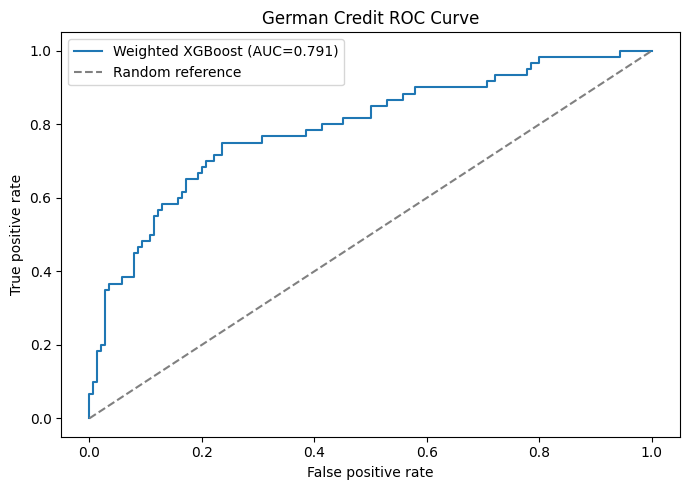

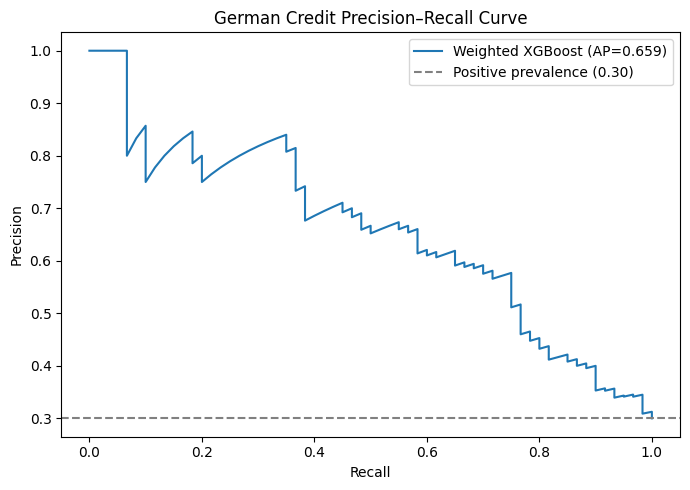

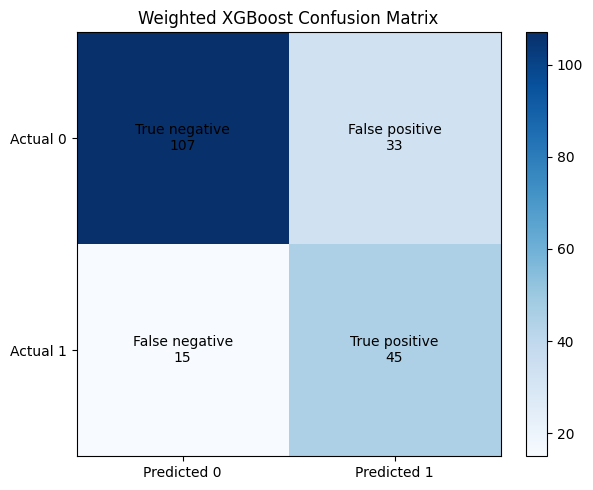

In [9]:
selected_model_changed = selected_final_model_name != previous_model_name
positive_prevalence = float(y_test.mean())
if selected_model_changed:
    fpr, tpr, _ = roc_curve(y_test, final_probabilities)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"{selected_final_model_name} (AUC={final_metrics['roc_auc']:.3f})")
    plt.plot([0, 1], [0, 1], "--", color="grey", label="Random reference")
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.title("German Credit ROC Curve"); plt.legend(); plt.tight_layout()
    plt.savefig(PLOTS_DIR / "german_credit_roc_curves.png", dpi=180, bbox_inches="tight")
    plt.show()

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, final_probabilities)
    plt.figure(figsize=(7, 5))
    plt.plot(recall_curve, precision_curve, label=f"{selected_final_model_name} (AP={final_metrics['pr_auc']:.3f})")
    plt.axhline(positive_prevalence, linestyle="--", color="grey", label=f"Positive prevalence ({positive_prevalence:.2f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("German Credit Precision–Recall Curve"); plt.legend(); plt.tight_layout()
    plt.savefig(PLOTS_DIR / "german_credit_precision_recall_curves.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(final_confusion, cmap="Blues")
    labels = np.array([["True negative", "False positive"], ["False negative", "True positive"]])
    for row in range(2):
        for column in range(2):
            ax.text(column, row, f"{labels[row, column]}\n{final_confusion[row, column]}", ha="center", va="center")
    ax.set_xticks([0, 1], ["Predicted 0", "Predicted 1"])
    ax.set_yticks([0, 1], ["Actual 0", "Actual 1"])
    ax.set_title(f"{selected_final_model_name} Confusion Matrix")
    fig.colorbar(image, ax=ax, fraction=0.046); plt.tight_layout()
    plt.savefig(PLOTS_DIR / "german_credit_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Selected estimator unchanged; existing final-model plots retained.")


## 9. Built-in importance sanity check


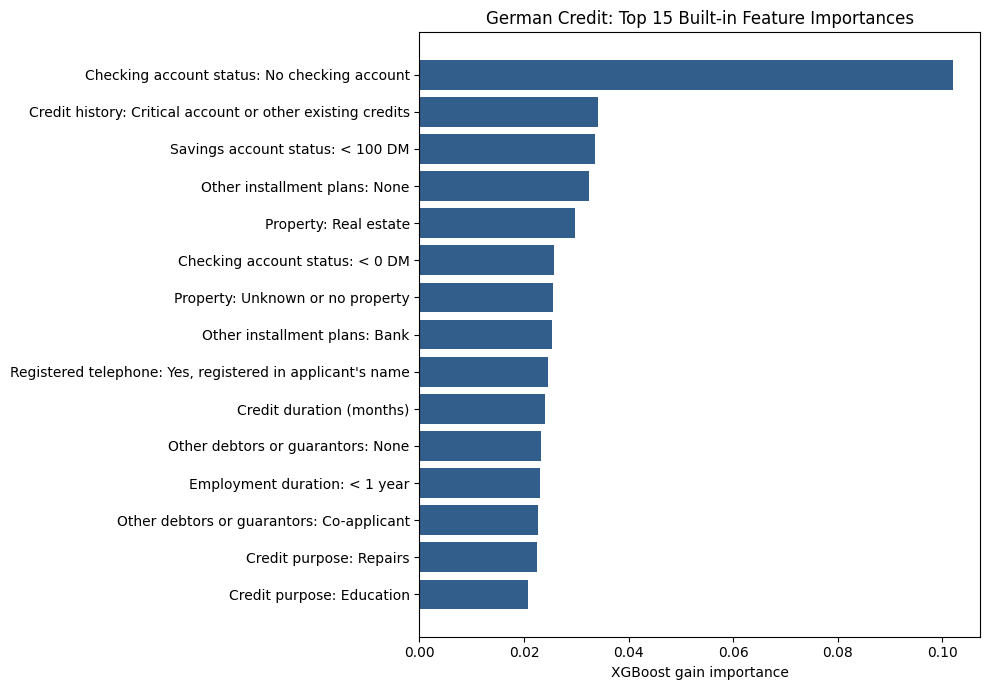

,rank,transformed_feature,original_feature,display_feature,category_label,importance
0,1,categorical__Attribute1_A14,Attribute1,Checking account status,No checking account,0.102139
1,2,categorical__Attribute3_A34,Attribute3,Credit history,Critical account or other existing credits,0.034230
2,3,categorical__Attribute6_A61,Attribute6,Savings account status,< 100 DM,0.033679
3,4,categorical__Attribute14_A143,Attribute14,Other installment plans,None,0.032451
4,5,categorical__Attribute12_A121,Attribute12,Property,Real estate,0.029671
5,6,categorical__Attribute1_A11,Attribute1,Checking account status,< 0 DM,0.025748
6,7,categorical__Attribute12_A124,Attribute12,Property,Unknown or no property,0.025514
7,8,categorical__Attribute14_A141,Attribute14,Other installment plans,Bank,0.025287
8,9,categorical__Attribute19_A192,Attribute19,Registered telephone,"Yes, registered in applicant's name",0.024568
9,10,numeric__Attribute2,Attribute2,Credit duration (months),,0.023988


In [10]:
feature_importance = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "original_feature": transformed_mapping["original_feature"],
    "display_feature": transformed_mapping["display_feature"],
    "category_label": transformed_mapping["category_label"],
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
feature_importance.insert(0, "rank", np.arange(1, len(feature_importance) + 1))
FEATURE_IMPORTANCE_PATH = ARTIFACTS_DIR / "model_feature_importance.csv"
if selected_model_changed or not FEATURE_IMPORTANCE_PATH.exists():
    feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
    plot_data = feature_importance.head(15).sort_values("importance")
    plot_labels = plot_data.apply(
        lambda row: f"{row['display_feature']}: {row['category_label']}" if row["category_label"] else row["display_feature"], axis=1
    )
    plt.figure(figsize=(10, 7))
    plt.barh(plot_labels, plot_data["importance"], color="#315E8A")
    plt.xlabel("XGBoost gain importance")
    plt.title("German Credit: Top 15 Built-in Feature Importances")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "german_credit_xgboost_feature_importance.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    saved_importance = pd.read_csv(FEATURE_IMPORTANCE_PATH, keep_default_na=False)
    assert saved_importance["transformed_feature"].tolist() == feature_importance["transformed_feature"].tolist()
    assert np.allclose(saved_importance["importance"], feature_importance["importance"])
    print("Selected estimator unchanged; existing importance artifacts retained.")
display(feature_importance.head(15))


## 10. Freeze model and corrected metadata


In [11]:
joblib.dump(final_model, MODEL_PATH)
selected_parameters = final_model.get_params()
saved_hyperparameters = {
    key: selected_parameters[key]
    for key in [
        "n_estimators", "max_depth", "learning_rate", "min_child_weight",
        "subsample", "colsample_bytree", "reg_alpha", "reg_lambda",
        "objective", "eval_metric", "random_state", "tree_method",
    ]
}
if selected_final_model_name == "Weighted XGBoost":
    saved_hyperparameters["scale_pos_weight"] = scale_pos_weight

selected_cv_metrics = selected_cv_row[
    ["roc_auc", "pr_auc", "balanced_accuracy", "precision_positive", "recall_positive", "f1_positive", "uci_cost"]
].to_dict()
model_metadata = {
    "dataset": "UCI Statlog German Credit Data (ID 144)",
    "xgboost_version": xgb.__version__,
    "random_state": RANDOM_STATE,
    "train_rows": 800, "test_rows": 200,
    "transformed_feature_count": 54,
    "positive_class": {"TARGET": 1, "original_class": 2, "meaning": "Bad / higher-risk credit"},
    "decision_threshold": DECISION_THRESHOLD,
    "selected_model_name": selected_final_model_name,
    "selected_hyperparameters": saved_hyperparameters,
    "scale_pos_weight": scale_pos_weight,
    "selection_scope": "training data only",
    "test_set_used_for_model_selection": False,
    "cross_validation_design": {
        "method": "StratifiedKFold", "n_splits": 5, "shuffle": True,
        "random_state": RANDOM_STATE, "scope": "training data only",
        "candidate_models": list(candidate_estimators),
    },
    "selection_rule": {
        "roc_auc_tolerance": SELECTION_TOLERANCE,
        "pr_auc_tolerance": SELECTION_TOLERANCE,
        "eligible_models": eligible_models["model"].tolist(),
        "tie_break_order": ["lower mean UCI cost", "higher mean positive F1", "higher mean balanced accuracy", "higher mean ROC-AUC"],
    },
    "selected_cv_mean_metrics": {key: float(value) for key, value in selected_cv_metrics.items()},
    "highest_cv_roc_auc": highest_cv_roc_auc,
    "highest_cv_pr_auc": highest_cv_pr_auc,
    "selection_reason": selection_reason,
    "test_metrics": final_metrics,
    "uci_cost_result": {
        "false_positive_cost": 1, "false_negative_cost": 5,
        "total_cost": final_metrics["uci_total_cost"],
        "average_cost": final_metrics["uci_average_cost"],
    },
    "training_time_seconds": final_training_time,
    "preprocessor_path": str(PREPROCESSOR_PATH.relative_to(BACKEND_DIR)),
    "train_index_path": str(TRAIN_INDICES_PATH.relative_to(BACKEND_DIR)),
    "test_index_path": str(TEST_INDICES_PATH.relative_to(BACKEND_DIR)),
}
MODEL_METADATA_PATH.write_text(json.dumps(model_metadata, indent=2), encoding="utf-8")
print(f"Model saved: {MODEL_PATH}")
print(f"Metadata saved: {MODEL_METADATA_PATH}")


Model saved: C:\Users\H P E L I T E\Desktop\XAI_CreditStudy\backend\artifacts\german_credit\xgboost_credit_model.joblib
Metadata saved: C:\Users\H P E L I T E\Desktop\XAI_CreditStudy\backend\artifacts\german_credit\model_metadata.json


## 11. Frozen-model reproduction


In [12]:
reloaded_model = joblib.load(MODEL_PATH)
reproduced_probabilities = reloaded_model.predict_proba(X_test_processed)[:, 1]
maximum_probability_difference = float(np.max(np.abs(reproduced_probabilities - final_probabilities)))
assert maximum_probability_difference <= 1e-12
print(f"Frozen model loaded: {hasattr(reloaded_model, 'classes_')}")
print(f"Exact test rows reconstructed: {len(X_test_raw)}")
print("Frozen predictions reproduced: True")
print(f"Maximum probability difference: {maximum_probability_difference:.12g}")


Frozen model loaded: True
Exact test rows reconstructed: 200
Frozen predictions reproduced: True
Maximum probability difference: 0


## 12. Fixed XAI cases

The existing cohort is retained when the selected estimator is unchanged. If selection changes, the same deterministic four-group procedure rebuilds it.


In [13]:
case_candidates = pd.DataFrame({
    "row_index": X_test_raw.index.to_numpy(),
    "true_target": y_test.to_numpy(),
    "predicted_class": final_predictions,
    "predicted_probability": final_probabilities,
})
case_candidates["threshold_distance"] = (case_candidates["predicted_probability"] - DECISION_THRESHOLD).abs()
selection_groups = [
    ("high-confidence positive", 1, ["predicted_probability", "row_index"], [False, True]),
    ("borderline positive", 1, ["threshold_distance", "row_index"], [True, True]),
    ("high-confidence negative", 0, ["predicted_probability", "row_index"], [True, True]),
    ("borderline negative", 0, ["threshold_distance", "row_index"], [True, True]),
]
selected_frames, used_rows = [], set()
for case_type, predicted_class, sort_columns, ascending in selection_groups:
    available = case_candidates.loc[
        case_candidates["predicted_class"].eq(predicted_class)
        & ~case_candidates["row_index"].isin(used_rows)
    ].sort_values(sort_columns, ascending=ascending)
    group = available.head(5).copy()
    group["case_type"] = case_type
    selected_frames.append(group)
    used_rows.update(group["row_index"])
expected_xai_cases = pd.concat(selected_frames, ignore_index=True)
expected_xai_cases.insert(0, "case_id", [f"GER_XAI_{number:03d}" for number in range(1, len(expected_xai_cases) + 1)])
expected_xai_cases = expected_xai_cases[[
    "case_id", "row_index", "true_target", "predicted_class",
    "predicted_probability", "case_type",
]]

if selected_model_changed or previous_xai_cases.empty:
    expected_xai_cases.to_csv(XAI_CASES_PATH, index=False)
    xai_cases_changed = True
else:
    assert previous_xai_cases[["case_id", "row_index", "true_target", "predicted_class", "case_type"]].equals(
        expected_xai_cases[["case_id", "row_index", "true_target", "predicted_class", "case_type"]]
    )
    assert np.allclose(previous_xai_cases["predicted_probability"], expected_xai_cases["predicted_probability"])
    xai_cases_changed = False

xai_cases = pd.read_csv(XAI_CASES_PATH)
display(xai_cases.groupby("case_type").size().rename("cases").to_frame())
print(f"Selected estimator changed: {selected_model_changed}")
print(f"XAI evaluation cases changed: {xai_cases_changed}")


,cases
case_type,
borderline negative,5
borderline positive,5
high-confidence negative,5
high-confidence positive,5


Selected estimator changed: True
XAI evaluation cases changed: True


## 13. Integrity summary


In [14]:
assert len(X_train_raw) == 800 and len(X_test_raw) == 200
assert X_train_processed.shape == (800, 54) and X_test_processed.shape == (200, 54)
assert set(train_indices).isdisjoint(set(test_indices))
assert len(set(train_indices) | set(test_indices)) == 1000
assert np.isclose(DECISION_THRESHOLD, 0.50)
assert model_metadata["selection_scope"] == "training data only"
assert model_metadata["test_set_used_for_model_selection"] is False
assert MODEL_PATH.exists() and MODEL_METADATA_PATH.exists()
assert CV_MODEL_COMPARISON_PATH.exists() and MODEL_COMPARISON_PATH.exists()

print("Model selected using training CV only: True")
print("Test set used for model selection: False")
print("Test set used only for final evaluation after selection: True")
print("New train/test split created: False")
print("Preprocessor refitted: False")
print("Decision threshold changed: False")
print("Dataset 1 modified: False")
print("SHAP executed: False")
print("LIME executed: False")
print("DiCE executed: False")


Model selected using training CV only: True
Test set used for model selection: False
Test set used only for final evaluation after selection: True
New train/test split created: False
Preprocessor refitted: False
Decision threshold changed: False
Dataset 1 modified: False
SHAP executed: False
LIME executed: False
DiCE executed: False
